In [43]:
import os
import numpy as np
import pandas as pd
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import random

# Check if GPU is available
is_gpu = torch.cuda.is_available()
device = torch.device("cuda" if is_gpu else "cpu")
print(is_gpu)

True


In [44]:
from AI4PDEs_utils  import create_tensors_3D, create_tensors_2D, get_weights_linear_2D, create_solid_body_2D
from AI4PDEs_bounds import boundary_condition_2D_u, boundary_condition_2D_v
from AI4PDEs_bounds import boundary_condition_2D_p, boundary_condition_2D_cw

In [66]:
dt = 0.05                               # Time step (s)
dx = 1.0 ; dy = 1.0                     # Grid size (m)
Re = 0.01                                  # Viscosity
ub = 1                                  # Inflow speed (m/s)
nx = 256 ; ny = 256                     # Grid point
lx = dx * nx ; ly = dy * ny             # Domain size (m)
nlevel = int(math.log(ny, 2)) + 1       # Multigrid level
ntime = 1000                            # Time step
n_out = 100                             # Time step to save results
bias_initializer = torch.tensor([0.0])  # Initial bias as 0 for NNs

In [67]:
[w1, w2, w3, wA, w_res, diag] = get_weights_linear_2D(dx)

All the required 2D filters have been created successfully!
w1    => second order derivative  - (1,1,3,3)
w2    => first order derivative x - (1,1,3,3)
w3    => first order derivative y - (1,1,3,3)
wA    => second order derivative  - (1,1,3,3)
w_res => Restriction operation    - (1,1,3,3)
diag  => Diagonal component of wA - (1,1,1,1)


In [68]:
w1 = w1.to(device)
w2 = w2.to(device)
w3 = w3.to(device)

In [69]:
class AI4CFD(nn.Module):

    def __init__(self):
        super(AI4CFD, self).__init__()

        self.xadv = nn.Conv2d(1,1,3,1,0)
        self.yadv = nn.Conv2d(1,1,3,1,0)
        self.diff = nn.Conv2d(1,1,3,1,0)

        # Assign fixed stencil weights
        self.xadv.weight.data = w2
        self.yadv.weight.data = w3
        self.diff.weight.data = w1

        self.xadv.bias.data = bias_initializer
        self.yadv.bias.data = bias_initializer
        self.diff.bias.data = bias_initializer

    def forward(self, u_old, dt, n_iter=40):

        u_new = u_old.clone()

        for _ in range(n_iter):

            u_pad = F.pad(u_new, (1,1,1,1), mode='constant', value=0)

            ADx = self.xadv(u_pad)
            ADy = self.yadv(u_pad)
            AD2 = self.diff(u_pad)

            Lu = Re * AD2 - ub * ADx - ub * ADy

            residual = u_new - dt * Lu - u_old

            # Jacobi update
            u_new = u_new - residual

        return u_new

In [70]:
model = AI4CFD().to(device)

In [71]:
values_u, values_v, values_p, values_uu, values_vv, values_pp, b_uu, b_vv = create_tensors_2D(nx, ny)

All the required 2D tensors have been created successfully!
values_u  => u velocity [first step]  - (1,1,ny,nx)
values_v  => v velocity [first step]  - (1,1,ny,nx)
values_p  => pressure                 - (1,1,ny,nx)
b_uu      => v velocity [second step] - (1,1,ny+2,nx+2)
b_vv      => v velocity [second step] - (1,1,ny+2,nx+2)
values_uu => u velocity [first step]  - (1,1,ny+2,nx+2)
values_vv => v velocity [first step]  - (1,1,ny+2,nx+2)
values_pp => pressure                 - (1,1,ny+2,nx+2)


In [72]:
x = torch.arange(nx, device=device) * dx
y = torch.arange(ny, device=device) * dy
Y, X = torch.meshgrid(y, x, indexing="ij")

x0 = nx*dx/2
y0 = ny*dy/2
a  = 25.0

values_u = torch.zeros((1,1,ny,nx), device=device)

values_u[0,0,
         (torch.abs(X-x0)<=a) &
         (torch.abs(Y-y0)<=a)] = 1.0

In [73]:
def UNIT_TEST(c):
    mass = torch.sum(c)*dx*dy
    x_com = torch.sum(c*X)*dx*dy/mass
    y_com = torch.sum(c*Y)*dx*dy/mass
    var = torch.sum(c*((X-x_com)**2+(Y-y_com)**2))*dx*dy/mass
    return mass.item(), x_com.item(), y_com.item(), var.item()

In [74]:
mass_hist = []
t_hist = []

start = time.time()

with torch.no_grad():
    for itime in range(1, ntime+1):

        values_u = model(values_u, dt, n_iter=40)

        mass, x_com, y_com, var = UNIT_TEST(values_u)

        mass_hist.append(mass)
        t_hist.append(itime*dt)

        print("Time step:", itime)

end = time.time()
print("Elapsed time:", end-start)

Time step: 1
Time step: 2
Time step: 3
Time step: 4
Time step: 5
Time step: 6
Time step: 7
Time step: 8
Time step: 9
Time step: 10
Time step: 11
Time step: 12
Time step: 13
Time step: 14
Time step: 15
Time step: 16
Time step: 17
Time step: 18
Time step: 19
Time step: 20
Time step: 21
Time step: 22
Time step: 23
Time step: 24
Time step: 25
Time step: 26
Time step: 27
Time step: 28
Time step: 29
Time step: 30
Time step: 31
Time step: 32
Time step: 33
Time step: 34
Time step: 35
Time step: 36
Time step: 37
Time step: 38
Time step: 39
Time step: 40
Time step: 41
Time step: 42
Time step: 43
Time step: 44
Time step: 45
Time step: 46
Time step: 47
Time step: 48
Time step: 49
Time step: 50
Time step: 51
Time step: 52
Time step: 53
Time step: 54
Time step: 55
Time step: 56
Time step: 57
Time step: 58
Time step: 59
Time step: 60
Time step: 61
Time step: 62
Time step: 63
Time step: 64
Time step: 65
Time step: 66
Time step: 67
Time step: 68
Time step: 69
Time step: 70
Time step: 71
Time step: 72
T

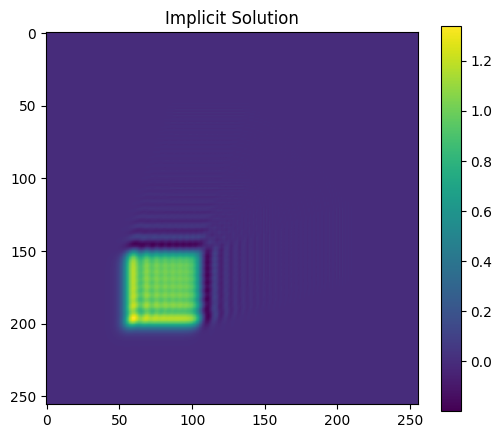

In [75]:
plt.figure(figsize=(6,5))
plt.imshow(values_u[0,0].cpu())
plt.colorbar()
plt.title("Implicit Solution")
plt.show()

In [76]:
print("Laplacian Stencil (Matrix Coefficients):\n", w1.squeeze())

Laplacian Stencil (Matrix Coefficients):
 tensor([[ 0.3333,  0.3333,  0.3333],
        [ 0.3333, -2.6667,  0.3333],
        [ 0.3333,  0.3333,  0.3333]], device='cuda:0')


In [77]:
print("X-Advection Stencil (Matrix Coefficients):\n", w2.squeeze())

X-Advection Stencil (Matrix Coefficients):
 tensor([[ 0.0833,  0.0000, -0.0833],
        [ 0.3333,  0.0000, -0.3333],
        [ 0.0833,  0.0000, -0.0833]], device='cuda:0')


In [78]:
print("Y-Advection Stencil (Matrix Coefficients):\n", w3.squeeze())

Y-Advection Stencil (Matrix Coefficients):
 tensor([[-0.0833, -0.3333, -0.0833],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0833,  0.3333,  0.0833]], device='cuda:0')


In [79]:
def print_sparse_matrix_equivalent(model, n=3):
    # Flattened size
    size = n * n
    matrix = torch.zeros((size, size))
    for i in range(size):
        # Create a unit vector (1 at position i)
        unit_vec = torch.zeros((1, 1, n, n)).to(device)
        unit_vec.view(-1)[i] = 1.0
        
        # Apply the operator L
        u_pad = F.pad(unit_vec, (1,1,1,1), mode='constant', value=0)
        # Assuming Re=0, ub=1 for simplicity
        Lu = - model.xadv(u_pad) - model.yadv(u_pad)
        
        # The result is the i-th column of the matrix
        matrix[:, i] = Lu.view(-1)
    
    print("Equivalent Sparse Matrix A (First derivative operators):")
    print(matrix.detach().cpu().numpy())

with torch.no_grad():
    print_sparse_matrix_equivalent(model, 3)

Equivalent Sparse Matrix A (First derivative operators):
[[-0.          0.33333334 -0.         -0.33333334  0.         -0.
  -0.         -0.         -0.        ]
 [-0.33333334 -0.          0.33333334 -0.16666667 -0.33333334  0.
  -0.         -0.         -0.        ]
 [-0.         -0.33333334 -0.         -0.         -0.16666667 -0.33333334
  -0.         -0.         -0.        ]
 [ 0.33333334  0.16666667 -0.         -0.          0.33333334 -0.
  -0.33333334  0.         -0.        ]
 [ 0.          0.33333334  0.16666667 -0.33333334 -0.          0.33333334
  -0.16666667 -0.33333334  0.        ]
 [-0.          0.          0.33333334 -0.         -0.33333334 -0.
  -0.         -0.16666667 -0.33333334]
 [-0.         -0.         -0.          0.33333334  0.16666667 -0.
  -0.          0.33333334 -0.        ]
 [-0.         -0.         -0.          0.          0.33333334  0.16666667
  -0.33333334 -0.          0.33333334]
 [-0.         -0.         -0.         -0.          0.          0.33333334
  -0.